##### Author: Rylee Albrecht

### Load and encode data

In [2]:
import zipfile
import pandas as pd
from sklearn.preprocessing import LabelEncoder

zip_path = "../data_processed.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    X_train_std = pd.read_csv(z.open('X_train_std.csv'))
    Y_train = pd.read_csv(z.open('Y_train.csv'))
    X_test_std  = pd.read_csv(z.open('X_test_std.csv'))
    Y_test  = pd.read_csv(z.open('Y_test.csv'))

unique_values = Y_train['diabetes_stage'].unique()
print("Unique values:", unique_values)
print(Y_train['diabetes_stage'].value_counts())

zip_path = "../data_processed_unstanderdized.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    X_train = pd.read_csv(z.open('X_train.csv'))
    X_test  = pd.read_csv(z.open('X_test.csv'))

# Identify categorical columns (dtype == object)
categorical_cols = X_train_std.select_dtypes(include=['object']).columns

# Apply one-hot encoding only to categorical columns
X_train_std_encoded = pd.get_dummies(X_train_std, columns=categorical_cols, drop_first=True)
X_test_std_encoded = pd.get_dummies(X_test_std, columns=categorical_cols, drop_first=True)
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure train and test have the same columns
X_test_std_encoded = X_test_std_encoded.reindex(columns=X_train_std_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

le = LabelEncoder()

# Fit on training labels and transform both train/test
Y_train_encoded = le.fit_transform(Y_train.values.ravel())
Y_test_encoded = le.transform(Y_test.values.ravel())

CLASS_LABELS = le.classes_

Unique values: ['Type 2' 'Pre-Diabetes' 'No Diabetes' 'Gestational' 'Type 1']
diabetes_stage
Type 2          44916
Pre-Diabetes    23740
No Diabetes      6044
Gestational       209
Type 1             91
Name: count, dtype: int64


### Helper functions for running grid search

In [10]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay


def run_grid_search_classification(model_pipeline, param_grid, X_train, y_train, X_test, y_test, cv=5, scoring='f1_weighted'):
    """
    Runs grid search using given model pipeline and param_grid 
    """
    start_time = time.time()

    # Convert y_train to 1D if needed
    if isinstance(y_train, pd.DataFrame):
        y_train = y_train.iloc[:, 0]

    # Grid Search
    grid_search = GridSearchCV(
        estimator=model_pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit=True,
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    cv_results = grid_search.cv_results_
    best_index = grid_search.best_index_
    mean_cv_f1 = cv_results['mean_test_score'][best_index]
    std_cv_f1 = cv_results['std_test_score'][best_index]

    # Compute CV accuracy for the best model separately
    cv_accuracy_scores = cross_val_score(
        best_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1
    )
    mean_cv_acc = cv_accuracy_scores.mean()
    std_cv_acc = cv_accuracy_scores.std()

    y_test_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

    if "feature_select" in best_model.named_steps or "select" in best_model.named_steps:
        if "feature_select" in best_model.named_steps:
            selector = best_model.named_steps["feature_select"]
        if "select" in best_model.named_steps:
            selector = best_model.named_steps["select"]
        
        mask = selector.get_support()

        selected_features = X_train.columns[mask]
        print("\n==============================")
        print(f"{len(selected_features)} Selected Features in the best model:")
        for f in selected_features:
            print(f)
        print("==============================\n")

    # CV results
    print("\nClassification report on test set:\n")
    print(classification_report(y_test, y_test_pred, zero_division=0))
    print("Best params:", best_params)
    print(f"CV weighted F1: {mean_cv_f1:.4f} ± {std_cv_f1:.4f}")
    print(f"CV accuracy: {mean_cv_acc:.4f} ± {std_cv_acc:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Test weighted F1: {test_f1_weighted:.4f}")

    elapsed_time = time.time() - start_time
    print(f"Elapsed time: {elapsed_time:.2f} s")

    return best_model, best_params


def plot_confusion_matrix(model, X_test, y_test, class_names, title="Confusion Matrix", filename="confusion_matrix.png"):
    """
    Plots Confusion Matrix for SVM or Bayes
    """
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)

    plt.savefig(filename, dpi=300, bbox_inches="tight")


def plot_roc_curves(model, X_test, y_test, class_names,  title="ROC Curves", filename="roc_curves.png"):
    """
    Plots ROC Curves for SVM or Bayes
    """
    classes = model.classes_
    n_classes = len(classes)

    # Binarize true labels
    y_test_bin = label_binarize(y_test, classes=classes)

    # Class scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
        if y_score.ndim == 1:
            y_score = np.vstack([-y_score, y_score]).T

    plt.figure(figsize=(10, 7))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.savefig(filename, dpi=300, bbox_inches="tight")



### Run grid search for SVM and get results

In [25]:
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline

# Base SVM pipeline
pipe_svm = Pipeline([
    ('select', SelectKBest(score_func=mutual_info_classif)),
    ('svc', SVC(class_weight='balanced'))
])

# Grid to search over top-k features + SVM hyperparameters
param_grid_svm = {
    'select__k': [10, 20, 30],
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto']
}

# Run your grid search
best_svm, best_params_svm = run_grid_search_classification(
    pipe_svm, param_grid_svm, 
    X_train_std_encoded, Y_train_encoded, 
    X_test_std_encoded, Y_test_encoded
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

30 Selected Features in the best model:
age
alcohol_consumption_per_week
physical_activity_minutes_per_week
diet_score
sleep_hours_per_day
bmi
waist_to_hip_ratio
systolic_bp
diastolic_bp
heart_rate
cholesterol_total
ldl_cholesterol
triglycerides
glucose_postprandial
insulin_level
family_history_diabetes
hypertension_history
gender_Male
ethnicity_Other
ethnicity_White
education_level_Highschool
education_level_No formal
education_level_Postgraduate
income_level_Lower-Middle
income_level_Middle
income_level_Upper-Middle
employment_status_Retired
employment_status_Unemployed
smoking_status_Former
smoking_status_Never


Classification report on test set:

              precision    recall  f1-score   support

           0       0.00      0.01      0.01        69
           1       0.39      0.79      0.53      1937
           2       0.60      0.67      0.63      8105
           3       0.00      0.00      0.00        31
      

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

selected_features_svm = [
    "age",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "cholesterol_total",
    "ldl_cholesterol",
    "triglycerides",
    "glucose_postprandial",
    "insulin_level",
    "family_history_diabetes",
    "hypertension_history",
    "gender_Male",
    "ethnicity_Other",
    "ethnicity_White",
    "education_level_Highschool",
    "education_level_No formal",
    "education_level_Postgraduate",
    "income_level_Lower-Middle",
    "income_level_Middle",
    "income_level_Upper-Middle",
    "employment_status_Retired",
    "employment_status_Unemployed",
    "smoking_status_Former",
    "smoking_status_Never",
]

# Select features
X_train_svm = X_train_std_encoded[selected_features_svm]
X_test_svm = X_test_std_encoded[selected_features_svm]

# Best SVM model from GridSearch
best_svm = SVC(
    C=1,
    gamma="scale",
    kernel="rbf",
    class_weight='balanced'
)

# Train
best_svm.fit(X_train_svm, Y_train_encoded)

# Predict
svm_pred = best_svm.predict(X_test_svm)

# Accuracy
print("Accuracy:", accuracy_score(Y_test_encoded, svm_pred))

# Weighted F1
weighted_f1 = f1_score(Y_test_encoded, svm_pred, average="weighted", zero_division=0)
print("Weighted F1:", weighted_f1)

# Classification report
print(classification_report(Y_test_encoded, svm_pred, zero_division=0))


Accuracy: 0.71164
Weighted F1: 0.7300695541266796
              precision    recall  f1-score   support

           0       0.00      0.01      0.01        69
           1       0.39      0.79      0.53      1937
           2       0.60      0.67      0.63      8105
           3       0.00      0.00      0.00        31
           4       0.93      0.73      0.82     14858

    accuracy                           0.71     25000
   macro avg       0.38      0.44      0.40     25000
weighted avg       0.77      0.71      0.73     25000



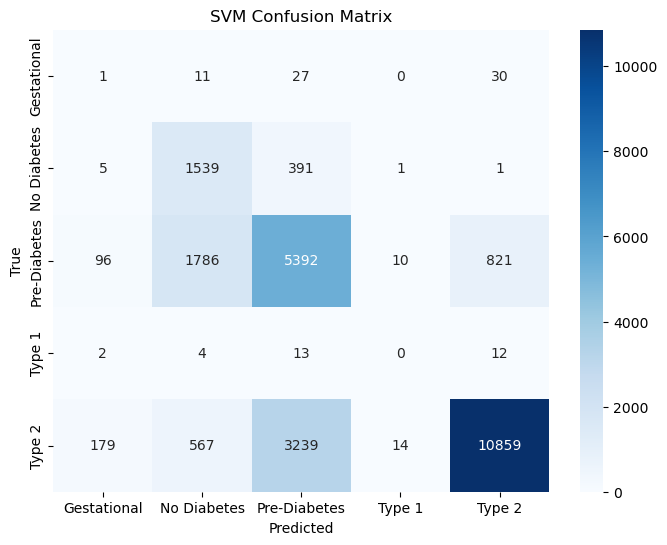

In [22]:
plot_confusion_matrix(best_svm, X_test_svm, Y_test_encoded, class_names=CLASS_LABELS, title="SVM Confusion Matrix", filename="confusion_matrix_svm")

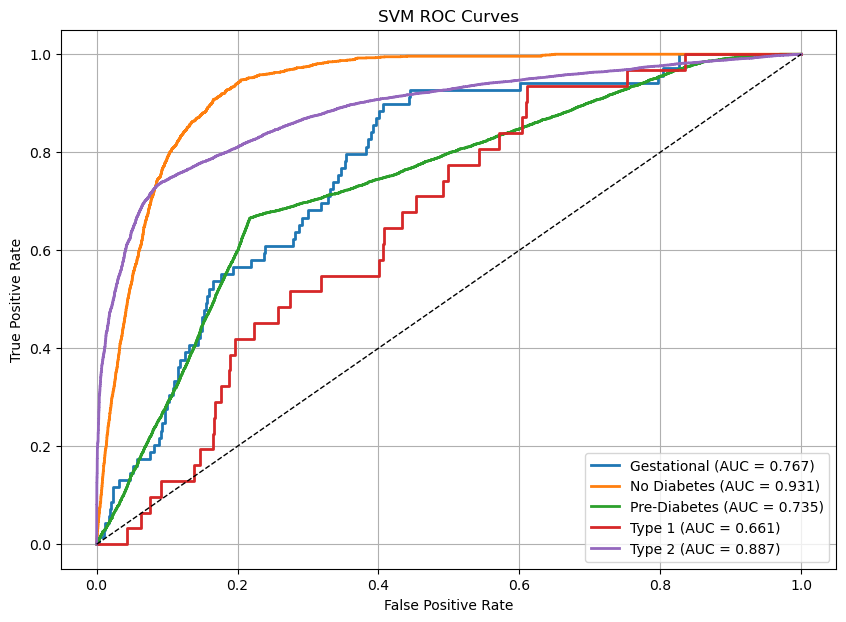

In [23]:
plot_roc_curves(best_svm, X_test_svm, Y_test_encoded, class_names=CLASS_LABELS, title="SVM ROC Curves", filename="roc_curves_svm")

### Run grid search for Naive Bayes and get results

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline

# Base NB model
nb = GaussianNB()

# Pipeline with forward selection
pipe_nb = Pipeline([
    ('feature_select', SequentialFeatureSelector(
        nb,
        direction='forward',
        scoring='f1_weighted',
        cv=3,
        n_jobs=-1
    )),
    ('nb', nb)
])

# Hyperparameters to search for NB
param_grid_nb = {
    'feature_select__n_features_to_select': [10, 20, 30],
    'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

# Run your grid search function
best_nb, best_params_nb = run_grid_search_classification(
    pipe_nb, param_grid_nb,
    X_train_encoded, Y_train_encoded,
    X_test_encoded, Y_test_encoded
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

20 Selected Features in the best model:
age
alcohol_consumption_per_week
sleep_hours_per_day
screen_time_hours_per_day
bmi
heart_rate
glucose_postprandial
ethnicity_Black
ethnicity_Hispanic
ethnicity_White
education_level_Highschool
education_level_Postgraduate
income_level_Low
income_level_Lower-Middle
income_level_Middle
income_level_Upper-Middle
employment_status_Retired
employment_status_Unemployed
smoking_status_Former
smoking_status_Never


Classification report on test set:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        69
           1       0.53      0.44      0.48      1937
           2       0.63      0.67      0.65      8105
           3       0.00      0.00      0.00        31
           4       0.85      0.85      0.85     14858

    accuracy                           0.75     25000
   macro avg       0.40      0.39      0.39     25000
weighted avg     

In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, f1_score

selected_features = [
    "age",
    "alcohol_consumption_per_week",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi",
    "heart_rate",
    "glucose_postprandial",
    "ethnicity_Black",
    "ethnicity_Hispanic",
    "ethnicity_White",
    "education_level_Highschool",
    "education_level_Postgraduate",
    "income_level_Low",
    "income_level_Lower-Middle",
    "income_level_Middle",
    "income_level_Upper-Middle",
    "employment_status_Retired",
    "employment_status_Unemployed",
    "smoking_status_Former",
    "smoking_status_Never",
]

X_train_encoded_nb = X_train_encoded[selected_features]
X_test_encoded_nb = X_test_encoded[selected_features]

# Define Model and fit
best_nb = GaussianNB(var_smoothing=1e-6)
best_nb.fit(X_train_encoded_nb, Y_train_encoded)

# Evaluate
y_pred = best_nb.predict(X_test_encoded_nb)

# Accuracy
print("Accuracy:", accuracy_score(Y_test_encoded, y_pred))

# Weighted F1
weighted_f1 = f1_score(Y_test_encoded, y_pred, average="weighted", zero_division=0)
print("Weighted F1:", weighted_f1)

# Full classification report
print(classification_report(Y_test_encoded, y_pred, zero_division=0))


Accuracy: 0.75284
Weighted F1: 0.7503519848242495
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        69
           1       0.53      0.44      0.48      1937
           2       0.63      0.67      0.65      8105
           3       0.00      0.00      0.00        31
           4       0.85      0.85      0.85     14858

    accuracy                           0.75     25000
   macro avg       0.40      0.39      0.39     25000
weighted avg       0.75      0.75      0.75     25000



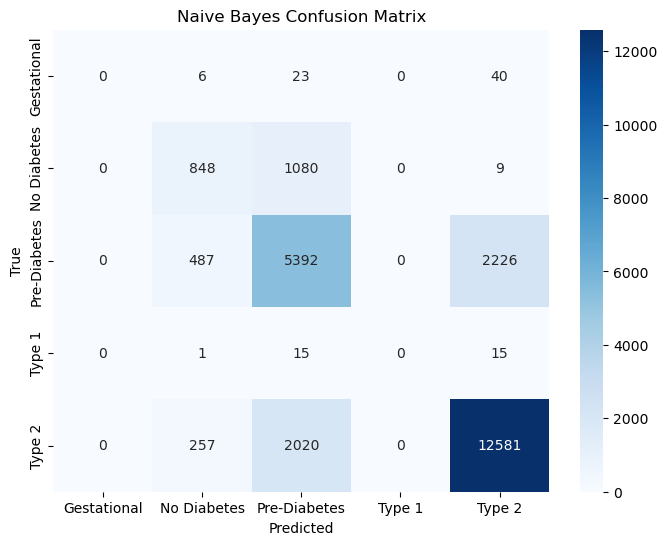

In [16]:
plot_confusion_matrix(best_nb, X_test_encoded_nb, Y_test_encoded, class_names=CLASS_LABELS, title="Naive Bayes Confusion Matrix", filename="confusion_matrix_nb")

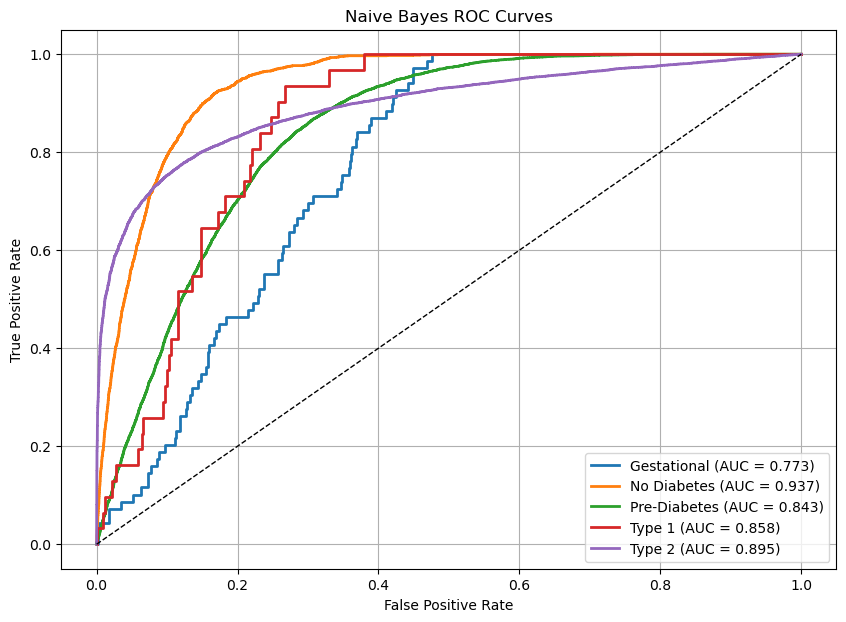

In [17]:
plot_roc_curves(best_nb, X_test_encoded_nb, Y_test_encoded, class_names=CLASS_LABELS, title="Naive Bayes ROC Curves", filename="roc_curves_nb")